# Least Squares

The following data set contains information about thirty work days in an accounting company. Every day the company receives invoices from its clients and processes them (e.g. checks them, enters them into the accounting system, etc.). The data set contains the number of invoices processed on each day and the time needed to process them. Our goal is to predict the time needed to process a given number of invoices.

Variables description:

-   `Day` (numeric): day
-   `Invoices` (numeric): number of invoices
-   `Time` (numeric): Time needed to process the invoices (hours)



In [ ]:
# Load the tidyverse packages and read the data

if (!require("tidyverse")) {
    install.packages("tidyverse")
}

library(tidyverse)

# Download and read the data
dt <- read_delim("https://github.com/febse/data/raw/refs/heads/main/econ/invoices.txt")

: 



Get an overview of the data set.



In [4]:
dt |> summary() 

      Day           Invoices          Time      
 Min.   : 1.00   Min.   : 23.0   Min.   :0.800  
 1st Qu.: 8.25   1st Qu.: 62.5   1st Qu.:1.500  
 Median :15.50   Median :127.5   Median :2.000  
 Mean   :15.50   Mean   :130.0   Mean   :2.110  
 3rd Qu.:22.75   3rd Qu.:189.5   3rd Qu.:2.775  
 Max.   :30.00   Max.   :289.0   Max.   :4.100  

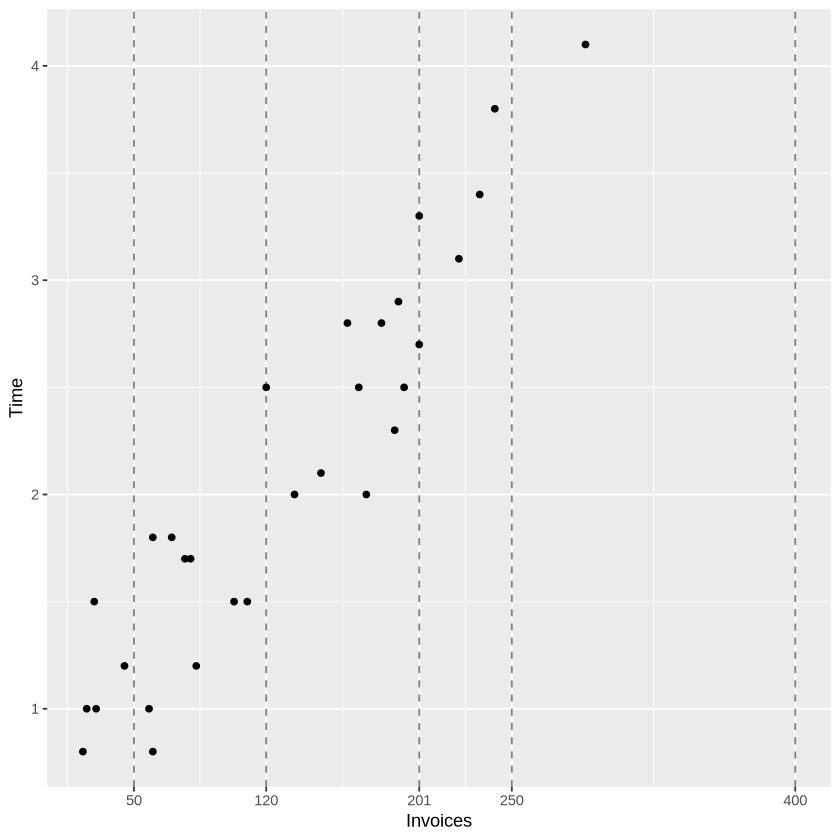

In [ ]:
#| label: fig-invoices-time
#| fig-cap: "Time needed to process the invoices"
#| code-fold: true

dt |>
  ggplot(aes(x = Invoices, y = Time)) +
    geom_point() +
    geom_vline(xintercept = c(50, 120, 201, 250), lty = 2, alpha = 0.5) +
    scale_x_continuous(breaks = c(50, 120, 201, 250))

## Strategy 1

Predict the working time using the average working time.

$$
\widehat{\text{Time}} = \overline{\text{Time}}
$$

Compute the residuals and store them in a columns called residuals_avg

In [ ]:
# Hint: use the mutate function

dt <- dt |>
    mutate(
        Time_predicted_avg = mean(Time),
        residuals_avg = ...
    )

## Strategy 2

$$
\widehat{\text{Time}} = 0.6 \text{Invoices}
$$


In [ ]:
dt <- dt |>
    mutate(
        Time_predicted_2 = ...,
        residuals_2 = ...
    )

## Strategy 3

$$
\widehat{Time} = 20 + 0.7 \text{Invoices}
$$

In [ ]:
dt <- dt |>
    mutate(
        Time_predicted_3 = ...,
        residuals_3 = ...
    )

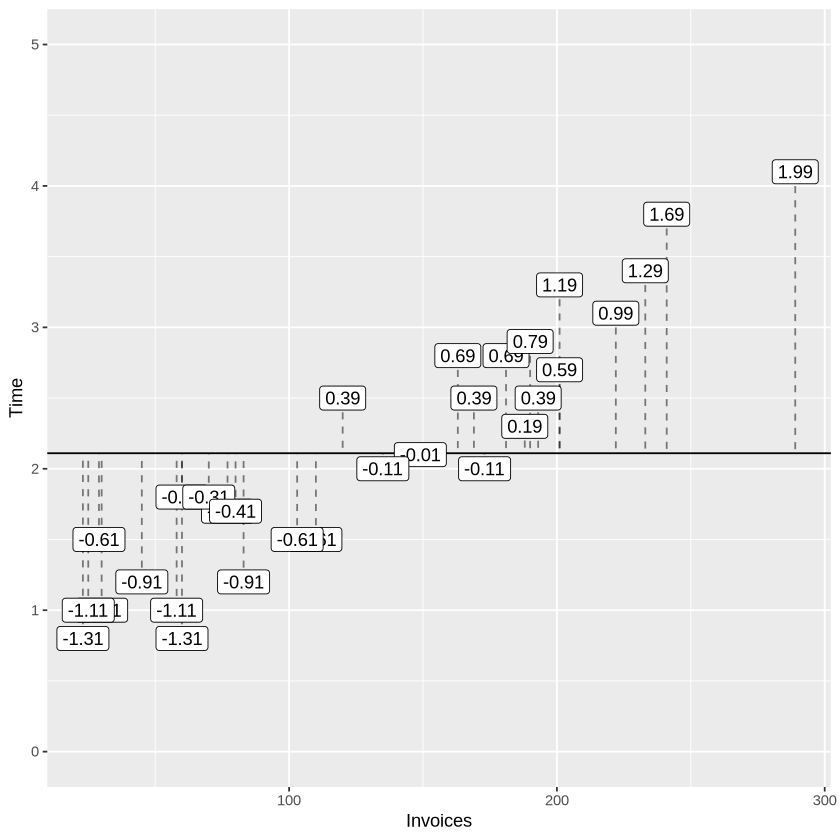

In [ ]:
#| label: fig-residuals-strategy-1
#| fig-cap: "Prediction and Residuals for Strategy 1"
#| code-fold: true

dt |>
    mutate(
        Time_predicted = mean(Time),
        residuals = Time - Time_predicted
    ) |>
    ggplot(aes(x = Invoices, y = Time)) +
    geom_point() +
    geom_hline(yintercept = mean(dt$Time), lty = 1) +
    geom_segment(
        aes(
            xend = Invoices,
            yend = mean(dt$Time)
            ), 
            lty = 2,
            alpha = 0.5
        ) +
    geom_label(aes(label = round(residuals, 1)))

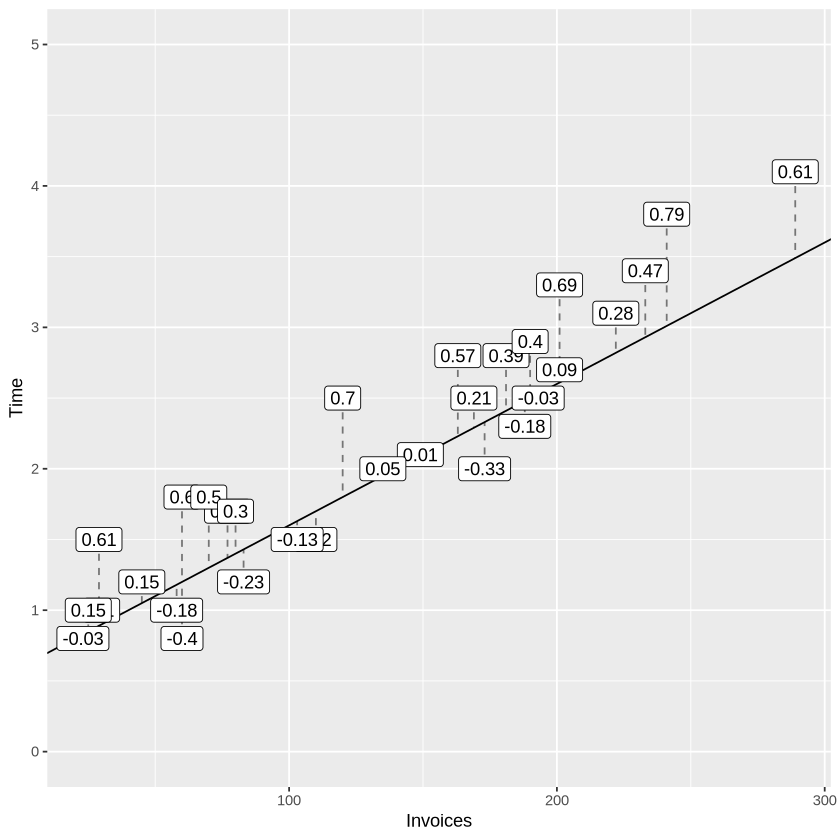

In [ ]:
#| label: fig-residuals-strategy-2
#| fig-cap: "Prediction and Residuals for Strategy 2"
#| code-fold: true

dt |>
    mutate(
        Time_predicted = 0.6 * Invoices,
        residuals = Time - Time_predicted
    ) |>
ggplot(aes(x = Invoices, y = Time)) +
  geom_point() +
  geom_abline(intercept = 0, slope = 0.6) +
  geom_segment(
    aes(
        xend = Invoices,
        yend = Time_predicted        
    ),
    alpha = 0.5,
    lty=2
    ) +
  geom_label(aes(label = round(residuals, 1)))

In [ ]:
#| label: fig-residuals-strategy-3
#| fig-cap: "Prediction and Residuals for Strategy 3"
#| code-fold: true

dt |>
    mutate(
        Time_predicted = 20 + 0.7 * Invoices,
        residuals = Time - Time_predicted
    ) |>
ggplot(aes(x = Invoices, y = Time)) +
  geom_point() +
  geom_abline(intercept = 20, slope = 0.7) +
  geom_segment(
    aes(
        xend = Invoices,
        yend = Time_predicted        
    ),
    alpha = 0.5,
    lty=2
    ) +
  geom_label(aes(label = round(residuals, 1)))

- [Desmos: the invoices data](https://www.desmos.com/calculator/9enmc8pooi)
- [Desmos: Least Squares with one variable](https://www.desmos.com/geometry/t5uupz5gmx)
- [Desmos: Least Squares with two variables ](https://www.desmos.com/3d/5oftsielgb)


Essence of linear algebra: [Youtube](https://www.youtube.com/watch?v=fNk_zzaMoSs&list=PLZHQObOWTQDPD3MizzM2xVFitgF8hE_ab)